## Milestone II - Baseline Model

XGBoost baseline classifier for recession prediction with time-based cross-validation.

**Input:** `data/milestone_ii_preprocessed.pkl` (fully engineered features from Preprocessing notebook)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    classification_report, roc_auc_score, precision_recall_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Load the preprocessed dataset
df = pd.read_pickle('data/milestone_ii_preprocessed.pkl')
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df.index.get_level_values('date').min()} to {df.index.get_level_values('date').max()}")
print(f"Countries: {df.index.get_level_values('country').unique().tolist()}")

Dataset shape: (5508, 237)
Date range: 1970-01-01 00:00:00 to 2020-12-01 00:00:00
Countries: ['Australia', 'Canada', 'France', 'Germany', 'Italy', 'Japan', 'South Korea', 'UK', 'USA']


### XGBoost Baseline Model

Test a baseline XGBoost classifier with time-based cross-validation. XGBoost handles missing values natively and doesn't require feature scaling.

**Key considerations:**
- **Time-based CV**: Split by date to avoid look-ahead bias (all countries at time t in same fold)
- **Class imbalance**: Use `scale_pos_weight` to handle rare recession events
- **Feature leakage**: Exclude `oecd_rec` and `technical_rec` (these are recession indicators)

In [2]:
# Reset index to work with date column
df_flat = df.reset_index()

# Drop COVID-19 period (2020 onwards) - exogenous shock with different dynamics
df_flat = df_flat[df_flat['date'] < '2020-01-01']
print(f"Filtered to pre-COVID period: {df_flat['date'].min().strftime('%Y-%m')} to {df_flat['date'].max().strftime('%Y-%m')}")

# Identify feature columns (exclude leaky and non-feature columns)
leaky_cols = ['oecd_rec', 'technical_rec', 'pre_recession']
non_feature_cols = ['date', 'country']
feature_cols = [c for c in df_flat.columns if c not in leaky_cols + non_feature_cols]

print(f"Total features: {len(feature_cols)}")
print(f"Total observations: {len(df_flat)}")

X = df_flat[feature_cols].copy()
y = df_flat['pre_recession']

# Replace inf/-inf with NaN (XGBoost handles NaN but not inf)
inf_count = np.isinf(X).sum().sum()
X = X.replace([np.inf, -np.inf], np.nan)
print(f"Replaced {inf_count} infinite values with NaN")

# Handle class imbalance
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
print(f"Class imbalance ratio: {scale_pos_weight:.2f}:1")
print(f"Positive class: {y.sum()} ({y.mean():.1%})")

Filtered to pre-COVID period: 1970-01 to 2019-12
Total features: 234
Total observations: 5400
Replaced 0 infinite values with NaN
Class imbalance ratio: 3.60:1
Positive class: 1173 (21.7%)


In [3]:
# Investigate Fold 5 issue: check pre-recession labels in 2019
df_check = df.reset_index()
df_2019 = df_check[(df_check['date'] >= '2019-01-01') & (df_check['date'] < '2020-01-01')]
print("2019 Pre-recession labels (these precede COVID recessions):")
print(f"  Total 2019 observations: {len(df_2019)}")
print(f"  Labeled as pre_recession=1: {df_2019['pre_recession'].sum()} ({df_2019['pre_recession'].mean():.1%})")
print(f"\nBy country:")
print(df_2019.groupby('country')['pre_recession'].agg(['sum', 'mean']).round(2))

# Option: Also exclude 2019 (pre-COVID contamination)
print("\n" + "="*60)
print("Re-running with 2019 also excluded (pre-COVID contamination)...")
print("="*60)

df_flat_clean = df.reset_index()
df_flat_clean = df_flat_clean[df_flat_clean['date'] < '2019-01-01']

X_clean = df_flat_clean[feature_cols].copy()
y_clean = df_flat_clean['pre_recession']
X_clean = X_clean.replace([np.inf, -np.inf], np.nan)

tscv = TimeSeriesSplit(n_splits=5)
cv_results_clean = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_clean)):
    X_train, X_test = X_clean.iloc[train_idx], X_clean.iloc[test_idx]
    y_train, y_test = y_clean.iloc[train_idx], y_clean.iloc[test_idx]
    
    train_dates = df_flat_clean.iloc[train_idx]['date']
    test_dates = df_flat_clean.iloc[test_idx]['date']
    
    spw = (y_train == 0).sum() / (y_train == 1).sum()
    
    model_clean = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=spw,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    model_clean.fit(X_train, y_train)
    y_proba = model_clean.predict_proba(X_test)[:, 1]
    
    roc_auc = roc_auc_score(y_test, y_proba)
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    
    cv_results_clean.append({'fold': fold + 1, 'roc_auc': roc_auc, 'pr_auc': pr_auc})
    
    print(f"Fold {fold + 1}: Train to {train_dates.max().strftime('%Y-%m')}, Test {test_dates.min().strftime('%Y-%m')}-{test_dates.max().strftime('%Y-%m')} | ROC-AUC: {roc_auc:.3f} | PR-AUC: {pr_auc:.3f}")

results_clean_df = pd.DataFrame(cv_results_clean)
print(f"\nSummary (excluding 2019+):")
print(f"  Mean ROC-AUC: {results_clean_df['roc_auc'].mean():.3f} ± {results_clean_df['roc_auc'].std():.3f}")
print(f"  Mean PR-AUC:  {results_clean_df['pr_auc'].mean():.3f} ± {results_clean_df['pr_auc'].std():.3f}")

2019 Pre-recession labels (these precede COVID recessions):
  Total 2019 observations: 108
  Labeled as pre_recession=1: 62 (57.4%)

By country:
             sum  mean
country               
Australia     11  0.92
Canada         8  0.67
France         5  0.42
Germany        0  0.00
Italy          5  0.42
Japan          5  0.42
South Korea    9  0.75
UK             8  0.67
USA           11  0.92

Re-running with 2019 also excluded (pre-COVID contamination)...
Fold 1: Train to 1978-02, Test 1978-03-1986-04 | ROC-AUC: 0.601 | PR-AUC: 0.322
Fold 2: Train to 1986-04, Test 1986-05-1994-06 | ROC-AUC: 0.667 | PR-AUC: 0.344
Fold 3: Train to 1994-06, Test 1994-07-2002-08 | ROC-AUC: 0.716 | PR-AUC: 0.479
Fold 4: Train to 2002-08, Test 2002-09-2010-10 | ROC-AUC: 0.758 | PR-AUC: 0.444
Fold 5: Train to 2010-10, Test 2010-11-2018-12 | ROC-AUC: 0.631 | PR-AUC: 0.298

Summary (excluding 2019+):
  Mean ROC-AUC: 0.675 ± 0.063
  Mean PR-AUC:  0.377 ± 0.080


Classification Metrics by Country (aggregated across all CV folds)
             Accuracy  Precision  Recall    F1  ROC-AUC  Support (pos)  Total
Country                                                                      
Australia       0.761      0.395   0.138 0.204    0.582            109    490
Canada          0.753      0.371   0.116 0.177    0.535            112    490
France          0.808      0.476   0.330 0.390    0.704             91    490
Germany         0.773      0.483   0.389 0.431    0.690            108    490
Italy           0.816      0.506   0.473 0.489    0.798             91    490
Japan           0.727      0.327   0.157 0.212    0.560            115    490
South Korea     0.743      0.462   0.146 0.222    0.580            123    490
UK              0.786      0.293   0.136 0.186    0.626             88    490
USA             0.812      0.509   0.312 0.387    0.732             93    490

Overall:  Accuracy=0.776  Precision=0.440  Recall=0.237  F1=0.308  ROC-AUC

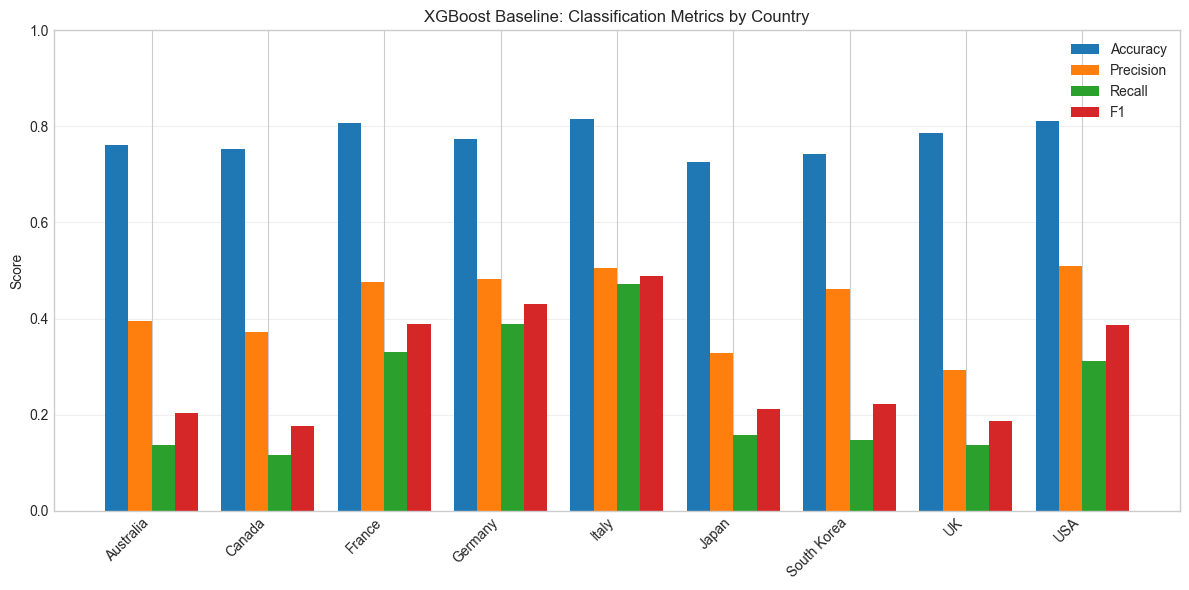

In [4]:
# Per-country classification metrics across all CV folds

# Re-run CV, collecting predictions with country labels
all_preds = []

tscv = TimeSeriesSplit(n_splits=5)
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_clean)):
    X_train, X_test = X_clean.iloc[train_idx], X_clean.iloc[test_idx]
    y_train, y_test = y_clean.iloc[train_idx], y_clean.iloc[test_idx]
    countries_test = df_flat_clean.iloc[test_idx]['country'].values

    spw = (y_train == 0).sum() / (y_train == 1).sum()

    model_clean = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=spw,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    model_clean.fit(X_train, y_train)
    y_pred = model_clean.predict(X_test)
    y_proba = model_clean.predict_proba(X_test)[:, 1]

    fold_df = pd.DataFrame({
        'country': countries_test,
        'y_true': y_test.values,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'fold': fold + 1
    })
    all_preds.append(fold_df)

pred_df = pd.concat(all_preds, ignore_index=True)

# Compute per-country metrics
country_metrics = []
for country in sorted(pred_df['country'].unique()):
    mask = pred_df['country'] == country
    yt = pred_df.loc[mask, 'y_true']
    yp = pred_df.loc[mask, 'y_pred']
    yprob = pred_df.loc[mask, 'y_proba']

    metrics = {
        'Country': country,
        'Accuracy': accuracy_score(yt, yp),
        'Precision': precision_score(yt, yp, zero_division=0),
        'Recall': recall_score(yt, yp, zero_division=0),
        'F1': f1_score(yt, yp, zero_division=0),
        'ROC-AUC': roc_auc_score(yt, yprob) if yt.nunique() > 1 else np.nan,
        'Support (pos)': int(yt.sum()),
        'Total': len(yt)
    }
    country_metrics.append(metrics)

metrics_df = pd.DataFrame(country_metrics).set_index('Country')

print("Classification Metrics by Country (aggregated across all CV folds)")
print("=" * 90)
print(metrics_df.to_string(float_format='{:.3f}'.format))

# Overall metrics for comparison
print(f"\nOverall:  Accuracy={accuracy_score(pred_df['y_true'], pred_df['y_pred']):.3f}  "
      f"Precision={precision_score(pred_df['y_true'], pred_df['y_pred'], zero_division=0):.3f}  "
      f"Recall={recall_score(pred_df['y_true'], pred_df['y_pred'], zero_division=0):.3f}  "
      f"F1={f1_score(pred_df['y_true'], pred_df['y_pred'], zero_division=0):.3f}  "
      f"ROC-AUC={roc_auc_score(pred_df['y_true'], pred_df['y_proba']):.3f}")

# Grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))
plot_metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics_df))
width = 0.2

for i, metric in enumerate(plot_metrics):
    ax.bar(x + i * width, metrics_df[metric], width, label=metric)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_df.index, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('XGBoost Baseline: Classification Metrics by Country')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

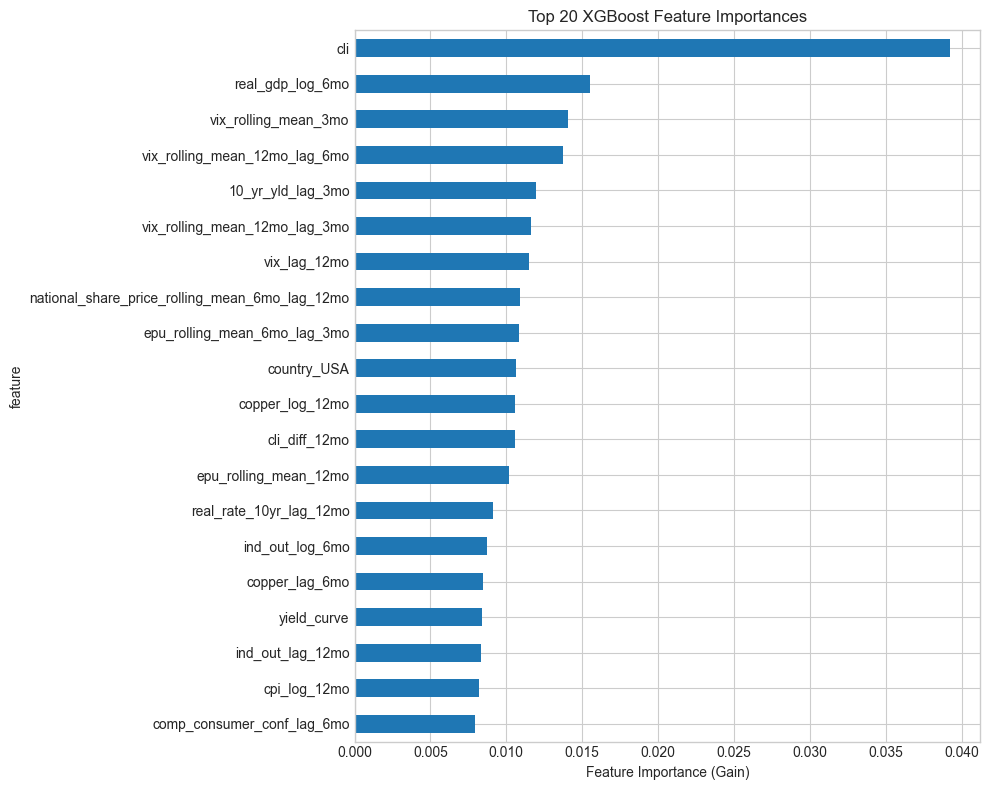


Top 10 most important features:
                                       feature  importance
                                           cli    0.039256
                              real_gdp_log_6mo    0.015512
                          vix_rolling_mean_3mo    0.014050
                 vix_rolling_mean_12mo_lag_6mo    0.013759
                             10_yr_yld_lag_3mo    0.011963
                 vix_rolling_mean_12mo_lag_3mo    0.011644
                                  vix_lag_12mo    0.011515
national_share_price_rolling_mean_6mo_lag_12mo    0.010891
                  epu_rolling_mean_6mo_lag_3mo    0.010834
                                   country_USA    0.010634


In [5]:
# Feature importance from the last fold model
importances = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_clean.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 20 features
fig, ax = plt.subplots(figsize=(10, 8))
top_n = 20
importances.head(top_n).plot(
    kind='barh', 
    x='feature', 
    y='importance', 
    ax=ax, 
    legend=False
)
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title(f'Top {top_n} XGBoost Feature Importances')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTop 10 most important features:")
print(importances.head(10).to_string(index=False))

#### XGBoost Baseline Summary

**Model Configuration:**
- XGBoost classifier with default hyperparameters (100 trees, max_depth=6, lr=0.1)
- `scale_pos_weight` to handle class imbalance
- Time-series cross-validation with 5 expanding window folds

**Key Observations:**
- XGBoost handles missing values natively - no imputation needed
- Time-based CV prevents look-ahead bias (critical for forecasting tasks)
- PR-AUC is more informative than ROC-AUC for imbalanced classes

**Next Steps for Improvement:**
1. Hyperparameter tuning (max_depth, learning_rate, n_estimators)
2. Feature selection based on importance scores
3. Try alternative thresholds based on precision-recall trade-offs
4. Compare with other models (Logistic Regression, Random Forest, LightGBM)